# Speaker diarization — BalanceCorpus audios

Batch-driver for [`scripts/diarize_speakers.py`](scripts/diarize_speakers.py). Runs `pyannote/speaker-diarization-3.1` (**2 speakers**) on every `.wav` in `audios/` and writes one CSV per file into `diarization/`, **mirroring the audio sub-folder structure**:

```
audios/103_203/103_203_12_..._board.wav   ->   diarization/103_203/103_203_12_..._board.csv
audios/108_208/....wav                     ->   diarization/108_208/....csv
```

Each CSV has columns `time_start, time_end, speaker` (as produced by the script).

In [17]:
# Install dependencies (run once). Restart the kernel afterwards if pyannote was just installed.
%pip install -q "pyannote.audio" soundfile

Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
from pathlib import Path

# ---- Configuration -------------------------------------------------------
BASE_DIR   = Path.cwd() / ".."                 # .../Datasets/BalanceCorpus
AUDIO_DIR  = BASE_DIR / "audios"
OUTPUT_DIR = BASE_DIR / "diarization"
SCRIPTS_DIR = BASE_DIR 
NUM_SPEAKERS = 2                        # each recording has 2 people
OVERWRITE = False                       # set True to re-run files that already have a CSV

# Make diarize_speakers.py importable and pull in its diarize_file().
sys.path.insert(0, str(SCRIPTS_DIR))
from diarize_speakers import diarize_file

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Audio dir :", AUDIO_DIR)
print("Output dir:", OUTPUT_DIR)

Audio dir : /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../audios
Output dir: /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../diarization


In [3]:
from tqdm.auto import tqdm

# Every wav, preserving its sub-folder (e.g. 103_203) so the output mirrors it.
wav_files = sorted(AUDIO_DIR.rglob("*.wav"))
print(f"Found {len(wav_files)} wav files")

errors = []
for wav_path in tqdm(wav_files, desc="Diarizing"):
    rel_dir = wav_path.parent.relative_to(AUDIO_DIR)   # e.g. Path('103_203')
    out_dir = OUTPUT_DIR / rel_dir
    out_csv = out_dir / (wav_path.stem + ".csv")

    if out_csv.exists() and not OVERWRITE:
        continue                                        # already processed

    try:
        diarize_file(
            str(wav_path),
            output_dir=str(out_dir),
            output_stem=wav_path.stem,                  # -> <name>.csv, mirrors the wav
            num_speakers=NUM_SPEAKERS,
        )
    except Exception as e:                              # keep going; collect failures
        errors.append((wav_path, repr(e)))

print(f"\nDone. {len(wav_files) - len(errors)} ok, {len(errors)} failed.")
for wav_path, err in errors:
    print("  FAILED", wav_path.name, "->", err)

Found 80 wav files


Diarizing:   0%|          | 0/80 [00:00<?, ?it/s]

/Users/m11/miniconda3/envs/story/lib/python3.12/site-packages/pyannote/audio/core/io.py:212: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  torchaudio.list_audio_backends()


  [Diarization] Loading: pyannote/speaker-diarization-3.1


/Users/m11/miniconda3/envs/story/lib/python3.12/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()
/Users/m11/miniconda3/envs/story/lib/python3.12/site-packages/pyannote/audio/core/io.py:212: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pyto

...

  [Diarization] Using MPS (Apple Silicon)
  [Diarization] Loading audio via soundfile: /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../audios/108_208/108_208_52_1_20250114_163842_blanket_board.wav
  [Diarization n_speakers=2] Processing... (this may take a while)
  [Diarization] Saved 4 segments → /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../diarization/108_208/108_208_52_1_20250114_163842_blanket_board.csv
  [Diarization] Loading: pyannote/speaker-diarization-3.1


/Users/m11/miniconda3/envs/story/lib/python3.12/site-packages/pyannote/audio/core/io.py:212: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  torchaudio.list_audio_backends()


  [Diarization] Using MPS (Apple Silicon)
  [Diarization] Loading audio via soundfile: /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../audios/108_208/108_208_53_1_20250114_163852_pillow_board.wav
  [Diarization n_speakers=2] Processing... (this may take a while)
  [Diarization] Saved 3 segments → /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../diarization/108_208/108_208_53_1_20250114_163852_pillow_board.csv
  [Diarization] Loading: pyannote/speaker-diarization-3.1


/Users/m11/miniconda3/envs/story/lib/python3.12/site-packages/pyannote/audio/core/io.py:212: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  torchaudio.list_audio_backends()


  [Diarization] Using MPS (Apple Silicon)
  [Diarization] Loading audio via soundfile: /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../audios/108_208/108_208_54_1_20250114_163903_soda_board.wav
  [Diarization n_speakers=2] Processing... (this may take a while)
  [Diarization] Saved 4 segments → /Users/m11/Documents/codes/TilburgMultiscaleSummerschool2026/Datasets/BalanceCorpus/orangediamond/../diarization/108_208/108_208_54_1_20250114_163903_soda_board.csv

Done. 80 ok, 0 failed.


## Quick check

Confirm the outputs landed in the mirrored structure and eyeball one CSV.

In [4]:
import pandas as pd

csvs = sorted(OUTPUT_DIR.rglob("*.csv"))
print(f"{len(csvs)} diarization CSVs under {OUTPUT_DIR}")
for c in csvs[:5]:
    print("  ", c.relative_to(OUTPUT_DIR))

if csvs:
    example = csvs[0]|
    print("\nExample:", example.relative_to(OUTPUT_DIR))
    display(pd.read_csv(example))

SyntaxError: invalid syntax (1035039624.py, line 9)

In [5]:
def merge_segments(df):
    """Glue all consecutive same-speaker turns into one turn (no gap limit)."""
    df = df.sort_values("time_start").reset_index(drop=True)

    merged = []
    for r in df.itertuples(index=False):
        if merged and r.speaker == merged[-1]["speaker"]:
            # same speaker as previous turn -> extend it
            merged[-1]["time_end"] = max(merged[-1]["time_end"], r.time_end)
        else:
            merged.append({"time_start": r.time_start,
                           "time_end": r.time_end,
                           "speaker": r.speaker})

    return pd.DataFrame(merged)


80 recordings, threshold = 0.5s


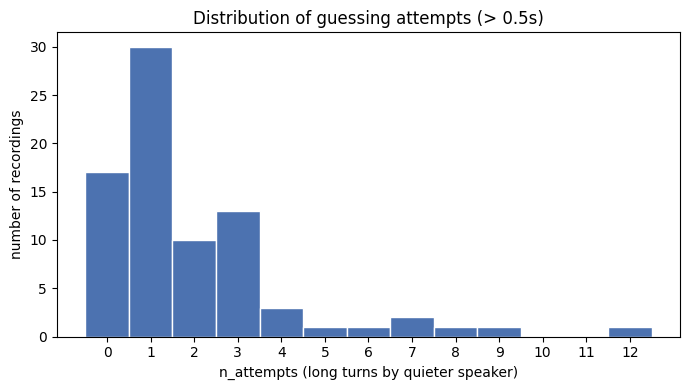

In [6]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path.cwd() /".."/ "diarization"   # adjust if needed
MIN_TURN_SEC = 0.5


def guessing_attempts(csv_path, min_turn_sec=MIN_TURN_SEC):
    """Count long turns by the speaker who spoke less in one diarization CSV."""
    df = pd.read_csv(csv_path)
    df["duration"] = df["time_end"] - df["time_start"]

    # Total speaking time per speaker -> the quieter one is the guesser.
    totals = df.groupby("speaker")["duration"].sum()
    quiet_speaker = totals.idxmin()

    quiet_turns = df[df["speaker"] == quiet_speaker]
    n_attempts = int((quiet_turns["duration"] > min_turn_sec).sum())

    return {
        "pair": csv_path.parent.name,
        "file": csv_path.stem,
        "quiet_speaker": quiet_speaker,
        "quiet_total_sec": round(float(totals.min()), 2),
        "loud_total_sec": round(float(totals.max()), 2),
        "n_attempts": n_attempts,
    }


csvs = sorted(OUTPUT_DIR.rglob("*.csv"))
attempts = pd.DataFrame([guessing_attempts(c) for c in csvs])
print(f"{len(attempts)} recordings, threshold = {MIN_TURN_SEC}s")



import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))

# integer-aligned bins so each count sits in its own bar
bins = range(attempts["n_attempts"].min(), attempts["n_attempts"].max() + 2)
ax.hist(attempts["n_attempts"], bins=bins, align="left",
        edgecolor="white", color="#4C72B0")

ax.set_xlabel("n_attempts (long turns by quieter speaker)")
ax.set_ylabel("number of recordings")
ax.set_title(f"Distribution of guessing attempts (> {MIN_TURN_SEC}s)")
ax.set_xticks(list(bins)[:-1])
plt.tight_layout()
plt.show()




In [7]:
!pip install faster-whisper


In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
import torch, torchaudio
from faster_whisper import WhisperModel

BASE_DIR      = Path.cwd()/".."                 # .../Datasets/BalanceCorpus
AUDIO_DIR     = BASE_DIR / "audios"
DIA_DIR       = BASE_DIR / "diarization"
TRANSCRIPT_DIR = BASE_DIR / "transcripts"
LANGUAGE      = "en"                        # set None to auto-detect
TARGET_SR     = 16000                       # whisper expects 16 kHz mono

# Load the ASR model once. "small" is a good speed/quality tradeoff; use "base" for faster.
model = WhisperModel("small", device="cpu", compute_type="int8")


def transcribe_segment(audio, sr, start, end):
    """Transcribe one [start, end] slice of a mono 16 kHz waveform."""
    seg = audio[int(start * sr): int(end * sr)]
    if seg.size == 0:
        return ""
    segments, _ = model.transcribe(seg, language=LANGUAGE, beam_size=1, vad_filter=False)
    return " ".join(s.text.strip() for s in segments).strip()


def transcribe_file(csv_path):
    """Merge same-speaker turns, transcribe each, then save."""
    rel = csv_path.relative_to(DIA_DIR).with_suffix(".wav")
    wav_path = AUDIO_DIR / rel
    if not wav_path.exists():
        raise FileNotFoundError(wav_path)

    # Load wav -> mono -> 16 kHz float32.
    data, sr = sf.read(str(wav_path), dtype="float32")
    wav = torch.from_numpy(data)
    if wav.ndim > 1:
        wav = wav.mean(dim=1)                       # stereo -> mono
    if sr != TARGET_SR:
        wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
    audio = wav.numpy()

    df = pd.read_csv(csv_path)
    df = merge_segments(df)                          # glue same-speaker turns
    df["text"] = [
        transcribe_segment(audio, TARGET_SR, r.time_start, r.time_end)
        for r in df.itertuples()
    ]

    # --- merge before saving ---
    out_path = TRANSCRIPT_DIR / csv_path.relative_to(DIA_DIR)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out_path, index=False)
    return df



csvs = sorted(DIA_DIR.rglob("*.csv"))
for csv_path in csvs[:3]:
    transcribe_file(csv_path)
    print("done", csv_path.relative_to(DIA_DIR))


done 103_203/103_203_12_1_20250113_152455_doughnut_board.csv
done 103_203/103_203_13_1_20250113_152513_spinach_board.csv
done 103_203/103_203_14_1_20250113_152536_balloon_board.csv
